In [1]:
from armor_tools import plot as plotter
from armor_tools import analysis 
from pathlib import Path
import pyart
import numpy as np
import pandas as pd


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [4]:
ROOT = Path('/nas/rhome/eebbert/armor/cfrad')

f_rhi = ROOT / 'ARMR20250820183028.nc'

f_snd = Path('/nas/rhome/eebbert/2025082018-72800.csv')

f_processed = Path('/nas/rhome/eebbert/ARMOR_20250820_183028_RHI_ZH_v1.nc')

In [6]:
import xarray as xr

ds = xr.open_dataset(f_processed)

print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:  (elevation: 555, range: 1041)
Dimensions without coordinates: elevation, range
Data variables:
    zh       (elevation, range) float32 2MB ...
Attributes:
    description:  Two-dimensional profile of equivalent radar reflectivity fa...


dict_keys(['HPower', 'VEL', 'SW', 'ZDR', 'PHI', 'RHO', 'SNR', 'REF', 'CFREF'])


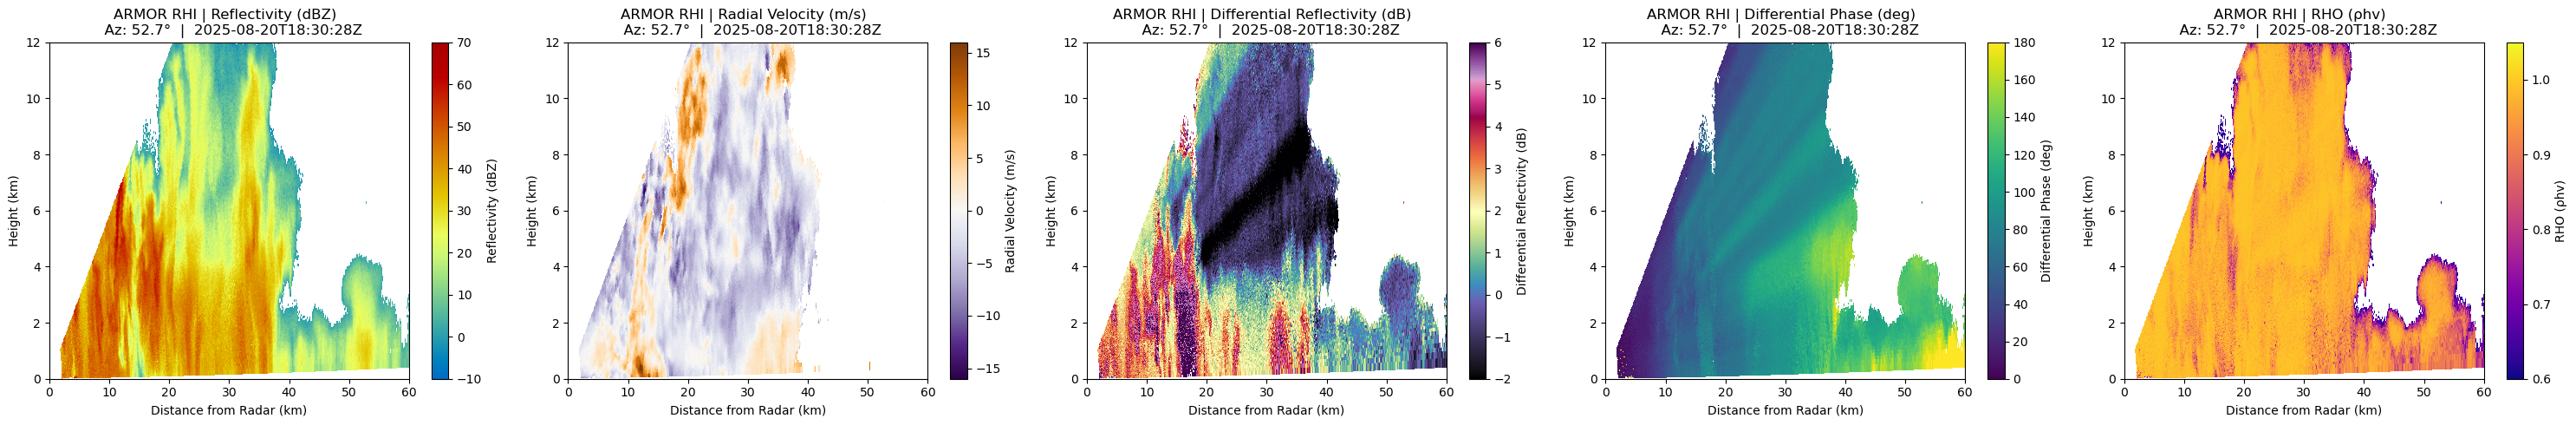

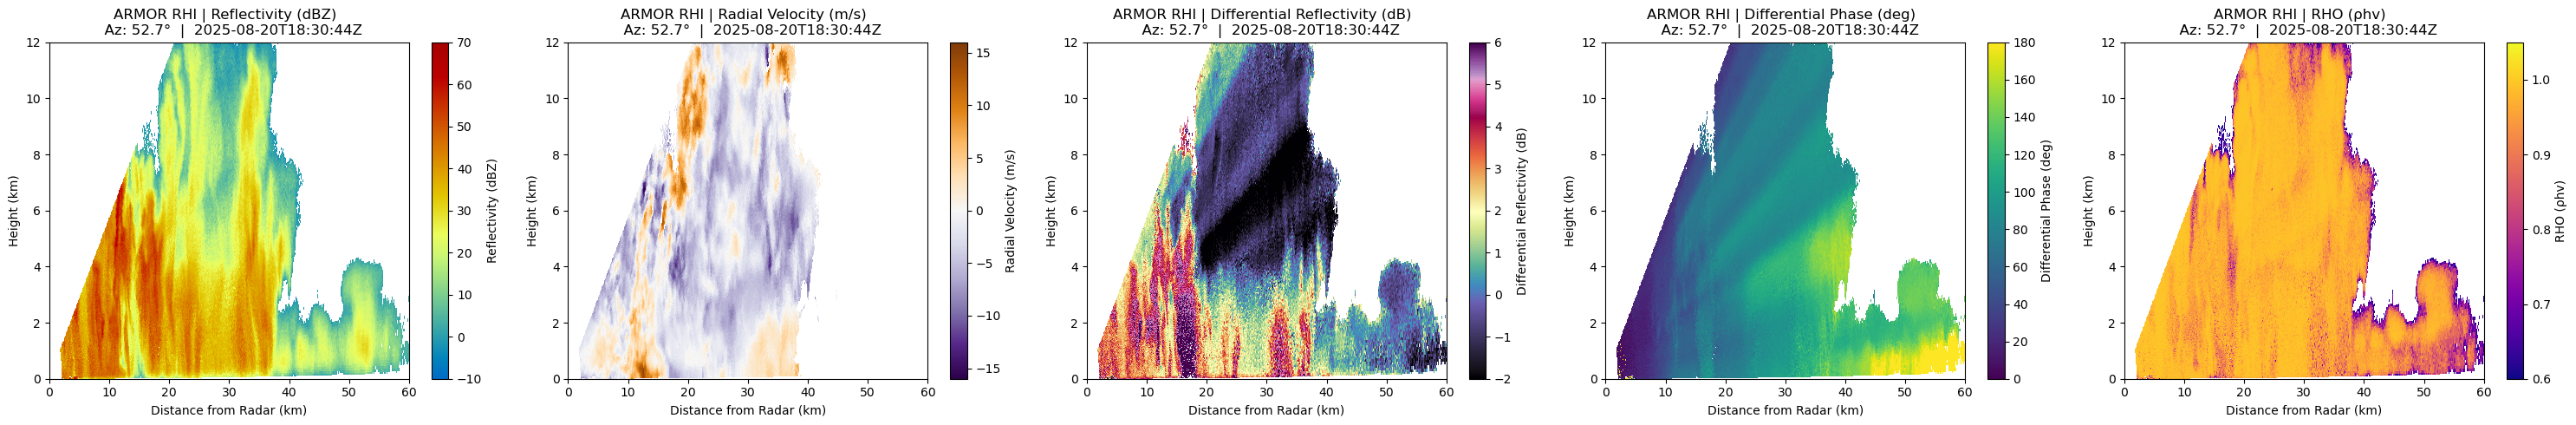

In [3]:
radar = pyart.io.read(f_rhi)
print(radar.fields.keys())

# QC 

# Values for clutter filtering
SNR = 5 # SNR threshold
RHO = 0.6 #rho hv threshold
fields_to_filter = ['REF', 'VEL', 'ZDR', 'RHO', 'PHI', 'SW']

# pointing angle offset
el_offset = 0.3

# correcting pointing angle
radar = analysis.correct_elevation_pointing_angle(radar, offset=el_offset)

# clutter filtering
for field in fields_to_filter:
    if field in radar.fields:
        radar = analysis.noise_filter(radar, field, SNR=SNR, rho=RHO)
    else:
        print(f'{field} not found in {f.name}')

# velocity dealiasing using Py-ART texture filter
if 'FVEL' in radar.fields:
    radar = analysis.dealias_velocity(radar, vel_field='FVEL')
else:
    print(f'FVEL not found in {f.name}, skipping dealiasing.')

# plotting
fields = ['FREF', 'FVEL', 'FZDR', 'FPHI', 'FRHO']

plotter.plot_rhi(radar=radar, fields=fields)

